## **Dataset**

In [75]:
from datasets import load_from_disk

data = load_from_disk("/root/mems_dataset")


In [84]:
# get only 100 random samples
d = data.shuffle(seed=42).select(range(1000))

In [ ]:
len(d['caption'])

1000

: 

In [78]:
import os
model = os.path.join("/root/.cache/huggingface/hub/model/text_encoder", "text_eer")
model

'/root/.cache/huggingface/hub/model/text_encoder/text_eer'

In [79]:
import os

os.environ["HTTP_PROXY"] = "http://172.168.1.240:4080"
os.environ["HTTPS_PROXY"] = "http://172.168.1.240:4080"

import torch
from transformers import CLIPTextModel, CLIPTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
text_encoder.eval()

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch16")

In [80]:
import os, glob
import torch
from transformers import CLIPTextModel, CLIPTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base = "/root/.cache/huggingface/hub/models--openai--clip-vit-base-patch16/snapshots"
cands = sorted(glob.glob(os.path.join(base, "*")))

if not cands:
    raise RuntimeError(f"No snapshot dirs under: {base}")

# 找一个真正包含权重文件的目录
model_dir = None
for d in reversed(cands):
    if (os.path.exists(os.path.join(d, "pytorch_model.bin"))
        or os.path.exists(os.path.join(d, "model.safetensors"))
        or os.path.exists(os.path.join(d, "flax_model.msgpack"))):
        model_dir = d
        break

if model_dir is None:
    raise RuntimeError(
        "Snapshots exist but no weights found. Model likely not fully downloaded.\n"
        f"Check: {base}"
    )

print("Using model_dir:", model_dir)

text_encoder = CLIPTextModel.from_pretrained(model_dir).to(device)
text_encoder.eval()
tokenizer = CLIPTokenizer.from_pretrained(model_dir)

Using model_dir: /root/.cache/huggingface/hub/models--openai--clip-vit-base-patch16/snapshots/57c216476eefef5ab752ec549e440a49ae4ae5f3


In [81]:
import torch
from transformers import CLIPTextModel, CLIPTokenizer
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
text_encoder = CLIPTextModel.from_pretrained("/root/.cache/huggingface/hub/models--openai--clip-vit-base-patch16/snapshots/57c216476eefef5ab752ec549e440a49ae4ae5f3").to(device)
text_encoder.eval()
tokenizer = CLIPTokenizer.from_pretrained("/root/.cache/huggingface/hub/models--openai--clip-vit-base-patch16/snapshots/57c216476eefef5ab752ec549e440a49ae4ae5f3")

In [82]:
x = len(ds["caption"])
x

1000

In [83]:
# ds["image"][0].save("text_to_image.png", format="PNG")

In [51]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CFMDataset(Dataset):
    def __init__(self, dataset, text_encoder, tokenizer, device):
        self.dataset = dataset
        self.transform = transforms.Compose(
            [transforms.Resize((128, 128)), transforms.ToTensor()]
            
        )
        self.text_encoder = text_encoder
        self.tokenizer = tokenizer
        self.device = device
        self.images = dataset["image"]
        self.captions = dataset["caption"]
        self.cache = {}

    def get_embed(self, caption):
        inputs = self.tokenizer(
            caption,
            truncation=True,
            padding=True,
            return_tensors="pt"
        ).to(self.device)
        self.text_encoder.eval()
        with torch.no_grad():
            # Use mean pooling instead of just the first token
            text_features = self.text_encoder(**inputs).last_hidden_state
            # Mean pooling
            text_features = text_features.mean(dim=1)
        return text_features.squeeze(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        if idx in self.cache:
            return self.cache[idx]

        transformed_image = self.transform(self.images[idx])
        caption = self.captions[idx]
        caption_embedding = self.get_embed(caption)

        item = {
            "image": transformed_image,
            "caption": caption,
            "caption_embedding": caption_embedding,
        }

        self.cache[idx] = item
        return item

In [53]:
train_ds = CFMDataset(ds, text_encoder, tokenizer, device)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

## **Model**

In [54]:
import math
import torch.nn as nn

# import sys
# print(sys.executable)
# print(sys.version)

from torchcfm.models.unet import UNetModel

def timestep_embedding(timesteps, dim, max_period=10000):
    """Create sinusoidal timestep embeddings.

    :param timesteps: a 1-D Tensor of N indices, one per batch element. These may be fractional.
    :param dim: the dimension of the output.
    :param max_period: controls the minimum frequency of the embeddings.
    :return: an [N x dim] Tensor of positional embeddings.
    """
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period)
        * torch.arange(start=0, end=half, dtype=torch.float32, device=timesteps.device)
        / half
    )
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

class UNetModelWithTextEmbedding(UNetModel):
    def __init__(self, dim, num_channels, num_res_blocks, embedding_dim, *args, **kwargs):
        super().__init__(dim, num_channels, num_res_blocks, *args, **kwargs)

        self.embedding_layer = nn.Linear(embedding_dim, num_channels*4)
        self.fc = nn.Linear(num_channels*8, num_channels*4)

    def forward(self, t, x, text_embeddings=None):
        """Apply the model to an input batch, incorporating text embeddings."""
        timesteps = t

        while timesteps.dim() > 1:
            timesteps = timesteps[:, 0]
        if timesteps.dim() == 0:
            timesteps = timesteps.repeat(x.shape[0])

        hs = []
        emb = self.time_embed(
            timestep_embedding(timesteps, self.model_channels)
        )

        if text_embeddings is not None:
            text_embedded = self.embedding_layer(text_embeddings)
            emb = torch.cat([emb, text_embedded], dim=1) # 128*2
            emb = self.fc(emb)

        h = x.type(self.dtype)
        for module in self.input_blocks:
            h = module(h, emb)
            hs.append(h)
        h = self.middle_block(h, emb)
        for module in self.output_blocks:
            h = torch.cat([h, hs.pop()], dim=1)
            h = module(h, emb)
        h = h.type(x.dtype)
        return self.out(h)

## **Training**

In [55]:
model = UNetModelWithTextEmbedding(
    dim=(3, 128, 128), num_channels=64, num_res_blocks=1, embedding_dim=512, dropout=0.05, num_heads=4
).to(device)
optimizer = torch.optim.AdamW(model.parameters())

In [70]:
from tqdm import tqdm

n_epochs = 10000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

for epoch in tqdm(range(n_epochs)):
    losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        x1 = batch["image"].to(device)
        text_embeddings = batch["caption_embedding"].to(device)

        x0 = torch.randn_like(x1).to(device)
        # print(x0.shape, x1.shape, text_embeddings.shape)

        t = torch.rand(x0.shape[0], 1, 1, 1).to(device)

        xt = t * x1 + (1 - t) * x0
        ut = x1 - x0

        t = t.squeeze()

        vt = model(t, xt, text_embeddings=text_embeddings)

        loss = torch.mean(((vt - ut) ** 2))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())

    avg_loss = sum(losses) / len(losses)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")

  1%|          | 100/10000 [00:54<1:30:19,  1.83it/s]

Epoch [100/10000], Loss: 0.0259


  2%|▏         | 200/10000 [01:48<1:29:01,  1.83it/s]

Epoch [200/10000], Loss: 0.0109


  3%|▎         | 300/10000 [02:43<1:28:10,  1.83it/s]

...

Epoch [2100/10000], Loss: 1.0087


 22%|██▏       | 2200/10000 [19:58<1:10:38,  1.84it/s]

Epoch [2200/10000], Loss: 1.0082


 23%|██▎       | 2296/10000 [20:50<1:09:56,  1.84it/s]


KeyboardInterrupt: 

In [58]:

torch.cuda.empty_cache()

## **Inference**

# Batch of sample test

In [59]:
model.eval()
def euler_method(model, text_embedding, t_steps, dt, noise):
    y = noise
    y_values = [y]
    with torch.no_grad():
        for t in t_steps[1:]:
            dy = model(
                t.to(device), y,
                text_embeddings=text_embedding
            )
            y = y + dy * dt
            y_values.append(y)
    return torch.stack(y_values)

# Initial random image and class (optional)
sample = next(iter(train_loader))
image = sample["image"].to(device)
text_embeddings = sample["caption_embedding"].to(device)
noise = torch.randn_like(image, device=device)

# Time parameters
t_steps = torch.linspace(0, 1, 50, device=device)
dt = t_steps[1] - t_steps[0]

# Solve the ODE using Euler method
results = euler_method(model, text_embeddings, t_steps, dt, noise)

# Single desired sample test

In [65]:
input_prompt = "drive_freq:32600Hz,split:between_3.0%_and_5.0%,parasitic:less_than_5000Hz,x_stiffness:8000N/m,nonlinearity:low"
text_embedding = train_ds.get_embed(input_prompt).unsqueeze(0)
noise = torch.randn((1, 3, 128, 128), device=device)
results = euler_method(model, text_embedding, t_steps, dt, noise)

In [66]:
torch.cuda.empty_cache()

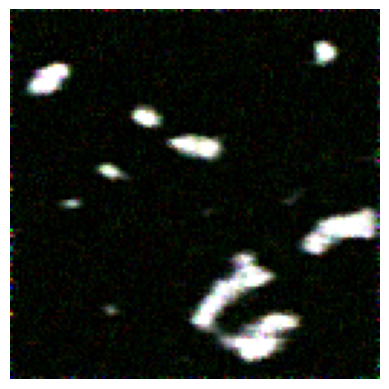

In [67]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

grid = make_grid(
    results[-1, -5:], padding=0, nrow=10
)
def tensor_to_image(tensor):
    return F.to_pil_image(tensor.clamp(0, 1))

img = tensor_to_image(grid)
plt.axis("off")
plt.imshow(img)
plt.show()

In [68]:
results.shape

torch.Size([50, 1, 3, 128, 128])

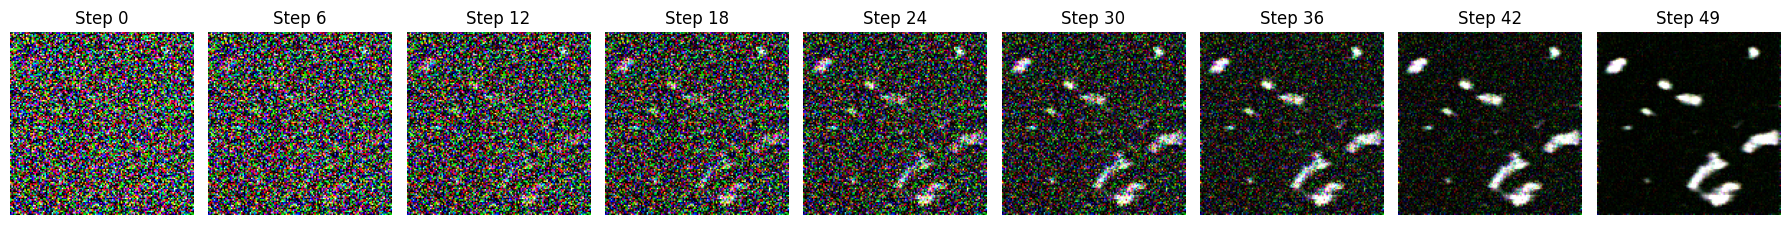

✅ Saved GIF to 'sample_0.gif'


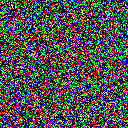

In [69]:
from IPython.display import display, Image as IPyImage

def show_and_save_sampling_progress(results, sample_idx=0, num_steps=9, save_path="sampling.gif", duration=300):
    """
    Hiển thị quá trình sampling (dạng ảnh) và đồng thời lưu thành file GIF.

    Args:
        traj (Tensor): Tensor 5D (T, B, C, H, W)
        sample_idx (int): Index của sample trong batch
        num_steps (int): Số bước sampling để hiển thị và lưu gif
        save_path (str): Đường dẫn file gif muốn lưu
        duration (int): Thời gian mỗi frame (milliseconds)
    """
    T = results.shape[0]
    assert num_steps <= T, "Số bước cần hiển thị phải nhỏ hơn hoặc bằng tổng số bước."

    # Lấy các bước cách đều từ 0 đến T-1
    indices = torch.linspace(0, T - 1, num_steps).long()

    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 2, 6))
    frames = []

    for i, idx in enumerate(indices):
        img_tensor = results[idx, sample_idx]  # (C, H, W)
        pil_img = tensor_to_image(img_tensor.cpu())
        frames.append(pil_img)

        # Hiển thị bằng matplotlib
        axes[i].imshow(pil_img)
        axes[i].axis("off")
        axes[i].set_title(f"Step {idx.item()}")

    plt.tight_layout()
    plt.show()

    # Save GIF
    frames[0].save(
        save_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0
    )
    print(f"✅ Saved GIF to '{save_path}'")

    display(IPyImage(filename=save_path))

sample_idx = 0
show_and_save_sampling_progress(results, sample_idx=sample_idx, num_steps=9, save_path=f"sample_{sample_idx}.gif")